## Семинар 5: "Улучшение сходимости нейросетей"

ФИО:

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
%matplotlib inline

## Описание задания:
Вам необходимо реализовать оставшиеся методы из лекции и сравнить их на примере из семинара.

## Задание разделено на следующие части:
1. Реализация Xavier **(1 балл)**

2.1 Реализация DropConnect **(1 балл)**

2.2 Сравнение обучения при использовании Dropout и DropConnect **(1 балл)**

3.1 Реализация LayerNorm **(1 балл)**

3.2 Сравнение обучения при использовании BatchNorm и LayerNorm **(1 балл)**

## Срок выполнения задания:
Данное задание можно сдать без штрафов до 16 октября.


### Часть 1: Инициализация весов

Будем использовать MNIST для обучения:

In [2]:
# Dataloader
to_numpy = lambda x: x.numpy()
transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                    ])
train_dataset = MNIST('.', train=True, download=True, transform=transform)
test_dataset = MNIST('.', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

In [3]:
images_train, labels_train = next(iter(train_loader))

In [4]:
## Usage example:
for X, y in train_loader:
    X = X.view(X.size(0), -1)
    X = X.numpy() ### Converts torch.Tensor to numpy array
    y = y.numpy()
    break

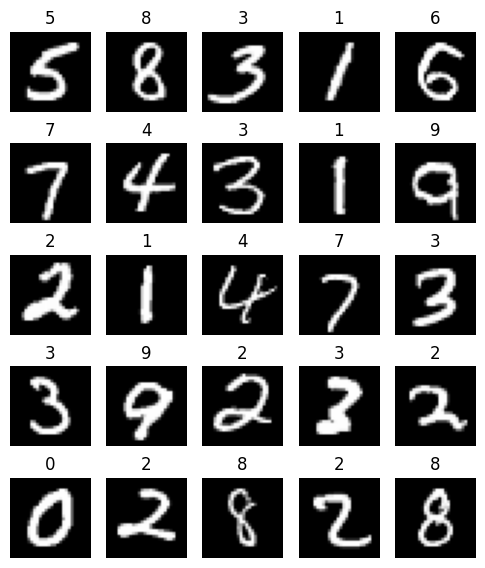

In [5]:
plt.figure(figsize=(6, 7))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.title(y[i])
    plt.axis('off')

In [6]:
def init_layer(layer, mean=0, std=1):
    # Тут надо быть аккуратным — можно случайно создать копию и менять значения у копии
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    weight.normal_(mean=mean, std=std)

def forward_hook(self, input_, output):
    std = input_[0].std().item()
    print('forward', std)

def backward_hook(self, grad_input, grad_output):
    std = grad_input[0].std().item()
    print('backward', std)

На вход передаем изображение 28x28, на выходе -- вероятности 10 классов.

In [7]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_layer(layer_1)
init_layer(layer_2)

Соберем все вместе, используя ReLU в качестве функции активации:

In [8]:
network = nn.Sequential(
    layer_1,
    nn.ReLU(),
    layer_2
)

In [9]:
def calulate(network):
    n_object = 100
    X = images_train[:n_object].view(n_object, -1).data
    y = labels_train[:n_object].data

    activation = network(X)
    loss_fn = torch.nn.NLLLoss()
    optimizer = torch.optim.Adam(network.parameters(), lr=1e-3)
    loss = loss_fn(activation, y)
    loss.backward()

#### 1.1 Реализуйте инициализацию Xavier. Сравните ее с He, которая была реализована на семинаре, сделайте выводы. Учтите, что для Xavier необходимо использовать функцию активации nn.Tanh(). **(1 балл)**

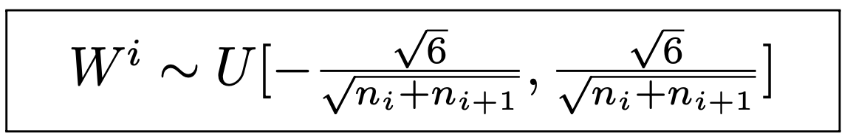

Инициализация базовая

In [10]:
calulate(network)

forward 1.017089605331421
forward 17.24745750427246


/home/Applications/Data/programming/2025/data-portfolio/skils/NN_skils/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


backward 0.03333333134651184
backward 0.1984557956457138


Инициализация He

In [11]:
class HeInit:
    @staticmethod
    def init_layer(layer: nn.Module, mean=0, std=1) -> None:
            weight = layer.state_dict()['weight']
            bias = layer.state_dict()['bias']
            bias.zero_()
            weight.normal_(mean=mean, std=std)

In [12]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

HeInit.init_layer(layer_1, 0, 2 / 500)
HeInit.init_layer(layer_2, 0, 2 / 10)

In [13]:
network = nn.Sequential(
    layer_1,
    nn.ReLU(),
    layer_2
)

In [14]:
calulate(network)

forward 1.017089605331421
forward 0.06816216558218002
backward 0.03333333134651184
backward 0.03837215527892113


In [15]:
class XavierInit:
    @staticmethod
    def init_layer(layer: nn.Module, from_ = 0, to = 1):
        weight: torch.Tensor = layer.state_dict()['weight']
        bias: torch.Tensor = layer.state_dict()['bias']
        bias.zero_()
        weight.uniform_(from_, to)

In [16]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

XavierInit.init_layer(layer_1, -1 * (6)**0.5 / (28*28 + 500)**0.5, 1 * (6)**0.5 / (28*28 + 500)**0.5)
XavierInit.init_layer(layer_2, -1 * (6)**0.5 / (500 + 10)**0.5, 1 * (6)**0.5 / (500 + 10)**0.5)

In [17]:
network = nn.Sequential(
    layer_1,
    nn.ReLU(),
    layer_2
)

In [18]:
calulate(network)

forward 1.017089605331421
forward 0.6825186610221863
backward 0.03333333134651184
backward 0.01213444396853447


В целом инициализация Xavier на сети с Relu показала себя лучше, так как дисперсия при прямом проходе показывает себя на порядок лучше, а градиенты в целом остались такие же

## Часть 2: DropConnect

#### 2.1 Реализуйте DropConnect по следующему шаблону: **(1 балл)**

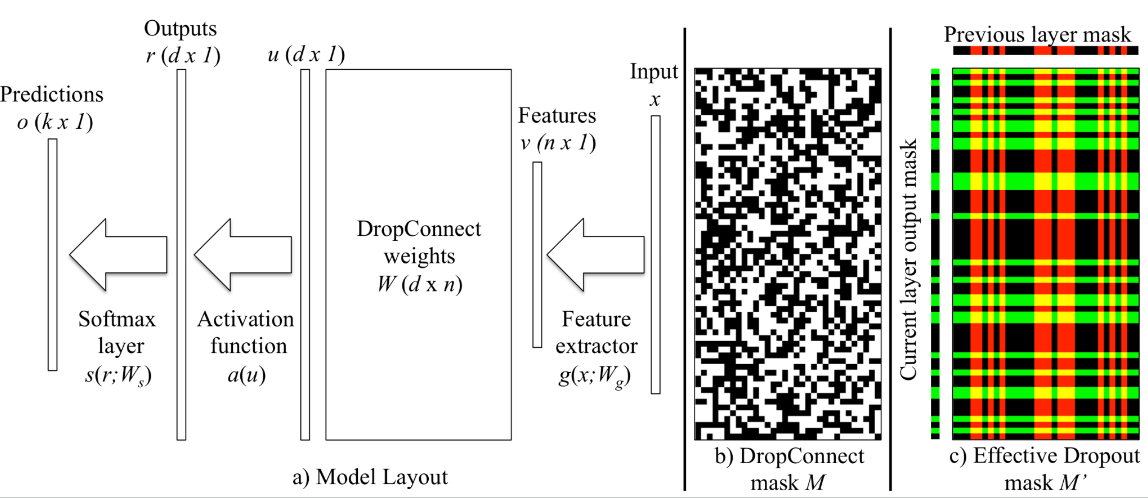

In [19]:
# полезная функция: .bernoulli_(p)
# не забывайте делать requires_grad=False у маски
# помните, что в вычислениях должны участвовать Variable, а не тензоры

class DropConnect(nn.Module):
    def __init__(self, input_dim, output_dim, p=0.5):
        super(DropConnect, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.bernoulli(torch.full_like(self.linear.weight, 1 - self.p, requires_grad=False))
        else:
            mask = torch.full_like(self.linear.weight, 1 - self.p, requires_grad=False)
            
        output = F.linear(x, self.linear.weight * mask, self.linear.bias)
        return output

Основа для сети, которую будем обучать:

In [20]:
class TestNetwork(nn.Module):
    def __init__(self, final_part):
        super().__init__()

        channels = 1

        self.conv_layers = nn.Sequential(
            nn.Conv2d(channels, 2, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(2, 4, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
        )

        #input_size = 7 * 7 * 4 = 196
        self.flatten = nn.Flatten()

        self.final_part = final_part

        self.log_softmax = nn.LogSoftmax(1)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.final_part(x)
        return self.log_softmax(x)

Добавим несколько слоев в конец сети:

In [21]:
layers = [
    nn.Linear(196, 128),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(128, 10)
]

In [22]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

Обучим получившуюся сеть:

In [23]:
losses_dict: dict[str, dict[str, list]] = { 'Dropout' : { 'train' : [], 'val' : [] }, 
                                           'DropConnect' : {'train' : [], 'val' : []},
                                           'BatchNormalization' : {'train' : [], 'val' : []}, 
                                           'LayerNormalization' : {'train' : [], 'val' : []},  
                                        }

In [ ]:
losses_dict['Dropout'].clear()
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses)))

    losses_dict['Dropout']['val'].append(np.mean(losses))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.300898
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.829858
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.561005
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.405103
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.439670
Test Epoch: 0	Loss: 0.225875
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.364004
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.352974
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.369621
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.337539
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.308994
Test Epoch: 1	Loss: 0.144424
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.204460
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.199022
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.247685
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.197019
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.220145
Test Epoch: 2	Loss: 0.114856
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.285565
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.229332
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.198865
Train Epoch: 3 [38400/60000 (64%)

In [25]:
layers = [
    DropConnect(196, 128),
    nn.ReLU(),
    DropConnect(128, 128),
    nn.ReLU(),
    DropConnect(128, 10),
]

In [26]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

In [ ]:
losses_dict['DropConnect'].clear()
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses)))

    losses_dict['DropConnect']['val'].append(np.mean(losses))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.307329
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.640589
Train Epoch: 0 [25600/60000 (43%)]	Loss: 1.191524
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.776817
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.636698
Test Epoch: 0	Loss: 0.516856
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.697445
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.871203
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.515814
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.625677
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.415233
Test Epoch: 1	Loss: 0.303766
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.481212
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.324936
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.380749
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.523216
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.484104
Test Epoch: 2	Loss: 0.242577
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.414961
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.351484
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.283802
Train Epoch: 3 [38400/60000 (64%)


#### 2.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Dropout между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и DropConnect вместо всех линейных слоев


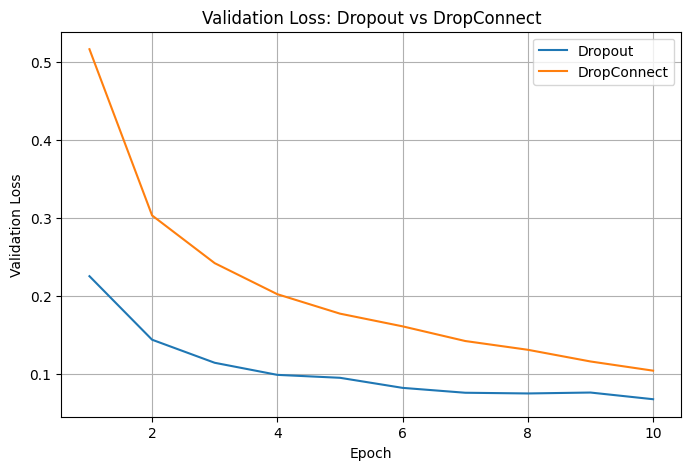

In [28]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(range(1, len(losses_dict['Dropout']['val']) + 1), 
        losses_dict['Dropout']['val'], label='Dropout')
ax.plot(range(1, len(losses_dict['DropConnect']['val']) + 1), 
        losses_dict['DropConnect']['val'], label='DropConnect')

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss: Dropout vs DropConnect")
ax.legend()
ax.grid(True)

plt.show()


DropConnection более плавная, по сравнению с Dropout, но нужно исследовать на больших эпохах. DropConnect падает медленее

### Часть 3: Batch Normalization

Наконец, давайте рассмотрим Batch Normalization. Этот слой вычитает среднее и делит на стандартное отклонение. Среднее и дисперсия вычисляются по батчу независимо для каждого нейрона. У этого слоя есть две важные проблемы: его нельзя использовать при обучении с размером батча 1 и он делает элементы батча зависимыми. Давайте реализуем аналог батч нормализации: <a href=https://arxiv.org/pdf/1607.06450.pdf>Layer normalization</a>. В layer normalization среднее и дисперсия вычисляются по активациям нейронов, независимо для каждого объекта.

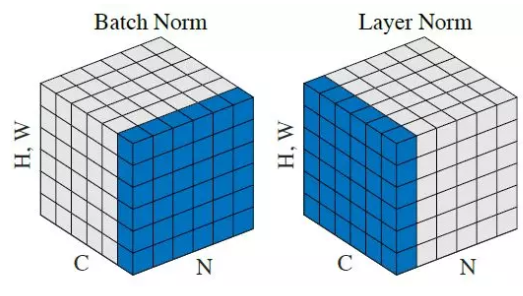

#### 3.1 Реализуйте Layer Normalization **(1 балл)**

In [39]:
# полезные функции: .std(dim), .mean(dim)

class LayerNormalization(nn.Module):
    def forward(self, x):
        output = (x - torch.mean(x, dim=1, keepdim=True)) / (torch.std(x, dim=1, keepdim=True) + 1e-5)
        return output

#### 3.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Batch normalization между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Layer normalization между всеми слоями

In [40]:
layers = [
    nn.Linear(196, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 10)
]

In [41]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

In [ ]:
losses_dict['BatchNormalization'].clear()
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses)))

    losses_dict['BatchNormalization']['val'].append(np.mean(losses))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.541875
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.163520
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.073674
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.108962
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.097385
Test Epoch: 0	Loss: 0.096355
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.151940
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.097634
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.091719
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.036167
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.113736
Test Epoch: 1	Loss: 0.066644
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.101348
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.045618
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.032110
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.115325
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.122948
Test Epoch: 2	Loss: 0.058855
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.048369
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.037715
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.012420
Train Epoch: 3 [38400/60000 (64%)

In [43]:
layers = [
    nn.Linear(196, 128),
    nn.ReLU(),
    LayerNormalization(),
    nn.Linear(128, 128),
    nn.ReLU(),
    LayerNormalization(),
    nn.Linear(128, 10)
]

In [44]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

In [ ]:
losses_dict['LayerNormalization'].clear()
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses)))

    losses_dict['LayerNormalization']['val'].append(np.mean(losses))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.438413
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.329687
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.189223
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.215924
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.226720
Test Epoch: 0	Loss: 0.160434
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.245646
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.122013
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.057282
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.097010
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.226020
Test Epoch: 1	Loss: 0.116132
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.119601
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.097209
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.152756
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.092129
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.071787
Test Epoch: 2	Loss: 0.083711
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.068282
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.033540
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.105181
Train Epoch: 3 [38400/60000 (64%)

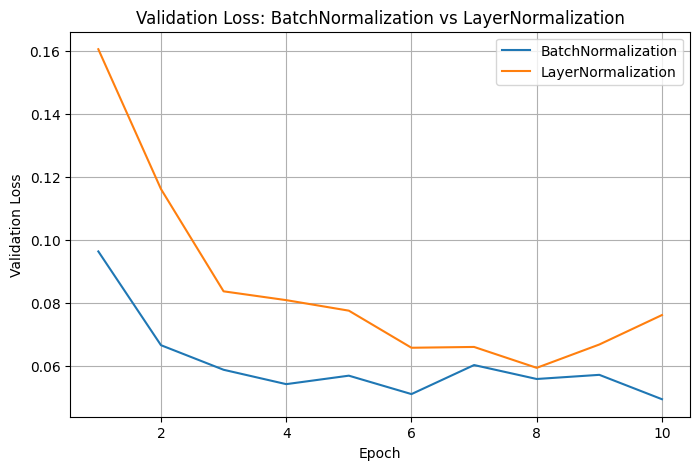

In [46]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(range(1, len(losses_dict['BatchNormalization']['val']) + 1), 
        losses_dict['BatchNormalization']['val'], label='BatchNormalization')
ax.plot(range(1, len(losses_dict['LayerNormalization']['val']) + 1), 
        losses_dict['LayerNormalization']['val'], label='LayerNormalization')

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss: BatchNormalization vs LayerNormalization")
ax.legend()
ax.grid(True)

plt.show()


Batch и Layer Normalization ускорили сходимость нейронной сети, в целом для чего они и были разработаны